# UNSW-NB15 Evaluation


In [11]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier

In [12]:
RANDOM_STATE = 1337

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "padme" / "src" / "main" / "resources" / "data"
OUT_DIR = DATA_DIR / "output"

TRAIN_PATH = DATA_DIR / "input" / "unsw_nb15_train.csv"
TEST_PATH = OUT_DIR / "unsw_nb15_test.csv"

MODES = ["baseline", "padme", "random"]

NODES = 5
BASELINE_NODE = 0

RATIOS = [0.02, 0.04, 0.06, 0.08, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

DROP_COLS = ["__id", "label", "attack_cat", "proto", "service", "state"]


In [13]:
def ratio_to_int(r: float) -> int:
    return int(round(r * 100))

def load_csv_any(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Não encontrei: {path}")
    return pd.read_csv(path)

def split_or_load_test(train_csv: Path, test_csv: Path, test_size: float = 0.2):
    df_train = load_csv_any(train_csv)

    if "label" not in df_train.columns:
        raise ValueError("Dataset de treino não tem coluna 'label'.")

    if test_csv.exists():
        df_test = load_csv_any(test_csv)
        if "label" not in df_test.columns:
            raise ValueError("Dataset de teste não tem coluna 'label'.")

        y_train = df_train["label"].astype(int).to_numpy()
        X_train = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns], errors="ignore")

        y_test = df_test["label"].astype(int).to_numpy()
        X_test = df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns], errors="ignore")

        return X_train, y_train, X_test, y_test

    y = df_train["label"].astype(int)
    X = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns], errors="ignore")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y
    )
    return X_train, y_train.to_numpy(), X_test, y_test.to_numpy()

X_train_full, y_train_full, X_test, y_test = split_or_load_test(TRAIN_PATH, TEST_PATH)

feature_cols = list(X_train_full.columns)

print("Train full:", X_train_full.shape, "Test:", X_test.shape, "Pos rate test:", float(np.mean(y_test)))

Train full: (50000, 31) Test: (2000, 31) Pos rate test: 0.6805


In [14]:
def node_file(mode: str, ratio_int: int | None, node_idx: int) -> Path:
    if mode == "baseline":
        return OUT_DIR / "baseline" / f"baseline_node{node_idx}.csv"
    return OUT_DIR / mode / str(ratio_int) / f"{mode}_node{node_idx}.csv"

def load_node_dataset(mode: str, ratio: float | None, node_idx: int):
    r_int = None if ratio is None else ratio_to_int(ratio)
    p = node_file(mode, r_int, node_idx)

    df = load_csv_any(p)
    if "label" not in df.columns:
        raise ValueError(f"{p} não tem coluna 'label'.")

    y = df["label"].astype(int).to_numpy()
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
    X = X.reindex(columns=feature_cols, fill_value=0.0)

    return X, y, str(p)

def pr_auc(model, Xtr, ytr, Xte, yte) -> float:
    model.fit(Xtr, ytr)
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(Xte)[:, 1]
    else:
        s = model.decision_function(Xte)
        p = 1 / (1 + np.exp(-s))
    return float(average_precision_score(yte, p))

In [15]:
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            solver="saga",
            max_iter=5000,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "HistGB": HistGradientBoostingClassifier(
        max_depth=None,
        learning_rate=0.1,
        max_iter=400,
        random_state=RANDOM_STATE
    )
}

In [16]:
rows = []

for model_name, model in models.items():
    Xb, yb, pb = load_node_dataset("baseline", None, BASELINE_NODE)
    base_score = pr_auc(model, Xb, yb, X_test, y_test)

    rows.append({
        "model": model_name,
        "mode": "baseline",
        "keep_ratio": 1.0,
        "ratio_int": 100,
        "node": BASELINE_NODE,
        "pr_auc": base_score,
        "pr_auc_mean": base_score,
        "pr_auc_std": 0.0
    })

    for mode in ["random", "padme"]:
        for r in RATIOS:
            scores = []
            for i in range(NODES):
                Xn, yn, pn = load_node_dataset(mode, r, i)
                s = pr_auc(model, Xn, yn, X_test, y_test)
                scores.append(s)

                rows.append({
                    "model": model_name,
                    "mode": mode,
                    "keep_ratio": r,
                    "ratio_int": ratio_to_int(r),
                    "node": i,
                    "pr_auc": s,
                    "file": pn
                })

            rows.append({
                "model": model_name,
                "mode": mode,
                "keep_ratio": r,
                "ratio_int": ratio_to_int(r),
                "node": "mean",
                "pr_auc": float(np.mean(scores)),
                "pr_auc_mean": float(np.mean(scores)),
                "pr_auc_std": float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0
            })

results = pd.DataFrame(rows)

results[(results["node"] == "mean") | (results["mode"] == "baseline")].sort_values(
    ["model","mode","keep_ratio"]
)

,model,mode,keep_ratio,ratio_int,node,pr_auc,pr_auc_mean,pr_auc_std,file
157,ExtraTrees,baseline,1.00,100,0,0.985875,0.985875,0.000000,NaN
241,ExtraTrees,padme,0.02,2,mean,0.965482,0.965482,0.003698,NaN
247,ExtraTrees,padme,0.04,4,mean,0.974583,0.974583,0.002632,NaN
253,ExtraTrees,padme,0.06,6,mean,0.976838,0.976838,0.001273,NaN
259,ExtraTrees,padme,0.08,8,mean,0.979468,0.979468,0.002488,NaN
...,...,...,...,...,...,...,...,...,...
54,LogReg,random,0.50,50,mean,0.941894,0.941894,0.004675,NaN
60,LogReg,random,0.60,60,mean,0.942271,0.942271,0.002225,NaN
66,LogReg,random,0.70,70,mean,0.940512,0.940512,0.002796,NaN
72,LogReg,random,0.80,80,mean,0.943594,0.943594,0.000826,NaN


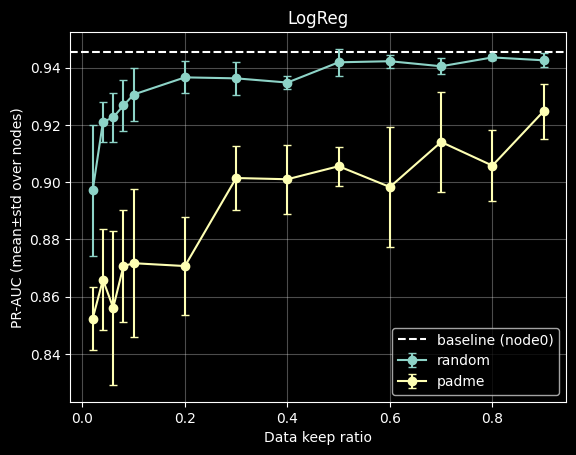

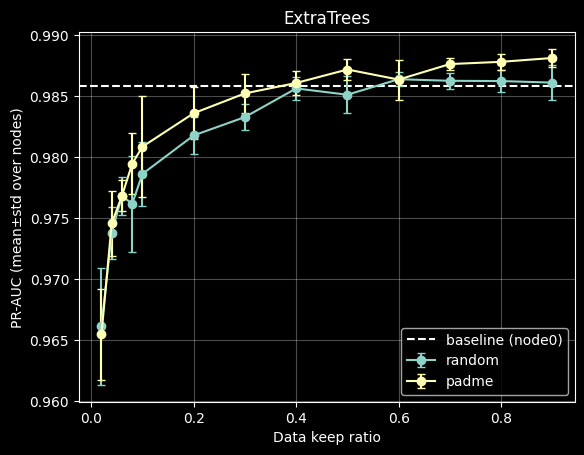

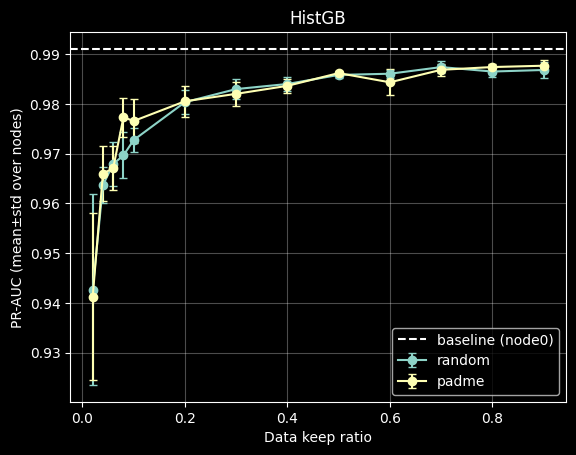

In [17]:
for model_name in models.keys():
    sub_mean = results[(results["model"] == model_name) & (results["node"] == "mean")].copy()
    base = results[(results["model"] == model_name) & (results["mode"] == "baseline")]["pr_auc_mean"].iloc[0]

    plt.figure()
    plt.axhline(base, linestyle="--", label=f"baseline (node{BASELINE_NODE})")

    for mode in ["random", "padme"]:
        s = sub_mean[sub_mean["mode"] == mode].sort_values("keep_ratio")
        plt.errorbar(
            s["keep_ratio"],
            s["pr_auc_mean"],
            yerr=s["pr_auc_std"],
            marker="o",
            capsize=3,
            label=mode
        )

    plt.xlabel("Data keep ratio")
    plt.ylabel("PR-AUC (mean±std over nodes)")
    plt.title(model_name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()